<a href="https://colab.research.google.com/github/maryamabdelkader/HAM10000-Skin-Lesion-Classification/blob/main/HAM10000_Skin_Lesion_Classification_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HAM10000 Skin Lesion Classification — Final Research Notebook

**Research question**

How do lesion-level data splitting, class-imbalance handling, clinical metadata, and prediction uncertainty affect the reliability and generalization of deep-learning models for multi-class skin-lesion classification?

This notebook uses a fixed lesion-level split, memory-safe image loading, training-only augmentation, and validation-based model selection. The locked test set is evaluated only after the final model is selected.


## Daily workflow

1. Run Sections **0–5**.
2. Confirm the split is **5942 / 2059 / 2014** with zero lesion overlap.
3. Restore existing checkpoints .
4. The metadata-fusion section restores the previously completed ablation and does not retrain it by default.

### Final analysis
Run the validation comparison, select the final model, then run the locked test evaluation,
advanced metrics, MC Dropout, calibration, and Grad-CAM analysis.


## Project structure in Google Drive

```text
HAM10000_Project/
├── train_split.csv
├── val_split.csv
├── test_split.csv
├── resnet50_frozen_ce.keras
├── resnet50_focal_loss.keras
├── resnet50_finetuned.keras
├── resnet50_balanced_sampling.keras
├── resnet50_balanced_finetuned.keras
├── resnet50_balanced_metadata_fusion.keras
└── new final-model checkpoints created by this notebook
```

The HAM10000 ZIP archive is also cached in this project folder so a new Colab runtime can rebuild `/content/ham10000` without downloading it again.

# 0. PROJECT SETUP

In [3]:
from google.colab import drive
drive.mount("/content/drive")

import os
import sys
import subprocess
import gc
import json
import pickle
import shutil
import zipfile
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    f1_score,
    accuracy_score,
    precision_recall_curve,
    average_precision_score,
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

#defines the location of project folder in Google Drive
PROJECT_DIR = "/content/drive/MyDrive/HAM10000_Project"
DATA_DIR = "/content/ham10000"
DATA_ZIP_DRIVE = os.path.join(
    PROJECT_DIR, "skin-cancer-mnist-ham10000.zip"
)
DATA_ZIP_LOCAL = "/content/skin-cancer-mnist-ham10000.zip"

#Create the HAM10000_Project folder if necessary; otherwise, continue normally.
os.makedirs(PROJECT_DIR, exist_ok=True)

#Because architectures such as ResNet50 commonly use 224 × 224 input images.
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 7

print("TensorFlow:", tf.__version__)
print("Project directory:", PROJECT_DIR)

#converts class labels into a binary format, where each class gets its own column.
from sklearn.preprocessing import label_binarize


Mounted at /content/drive
TensorFlow: 2.21.0
Project directory: /content/drive/MyDrive/HAM10000_Project


## 1. Dataset download/cache — first setup only

Run this cell once in the new account. If the ZIP is already in Drive, no Kaggle download is performed.

In [4]:
if os.path.exists(DATA_ZIP_DRIVE):
    print("HAM10000 archive already exists in Google Drive.")
else:
    print("HAM10000 archive not found in Drive. Downloading from Kaggle...")

    # Kaggle CLI is needed only for the first download.
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kaggle"])

    from getpass import getpass
    token = getpass("Paste your Kaggle API token: ")
    os.environ["KAGGLE_API_TOKEN"] = token

    subprocess.check_call([
        "kaggle", "datasets", "download",
        "-d", "kmader/skin-cancer-mnist-ham10000",
        "-p", "/content",
    ])

    shutil.copy2(DATA_ZIP_LOCAL, DATA_ZIP_DRIVE)
    print("Archive copied to Drive for future sessions.")


HAM10000 archive already exists in Google Drive.


## 2. Restore HAM10000 to temporary Colab storage


This cell is safe to run after every restart. It uses the Drive archive when `/content/ham10000` is missing.

In [5]:
METADATA_PATH = os.path.join(DATA_DIR, "HAM10000_metadata.csv")

if os.path.exists(METADATA_PATH):
    print("HAM10000 is already available in this runtime.")
else:
    if not os.path.exists(DATA_ZIP_DRIVE):
        raise FileNotFoundError(
            "HAM10000 archive is not in Drive. Run Section 1 once first."
        )

    print("Restoring HAM10000 from Drive...")
    shutil.copy2(DATA_ZIP_DRIVE, DATA_ZIP_LOCAL)

    with zipfile.ZipFile(DATA_ZIP_LOCAL, "r") as zip_ref:
        zip_ref.extractall(DATA_DIR)

    print("HAM10000 restored to temporary Colab storage.")

print("Metadata exists:", os.path.exists(METADATA_PATH))

Restoring HAM10000 from Drive...
HAM10000 restored to temporary Colab storage.
Metadata exists: True


# 3. LOAD METADATA AND IMAGE PATHS

In [6]:
df = pd.read_csv(METADATA_PATH)

image_dirs = [
    os.path.join(DATA_DIR, "HAM10000_images_part_1"),
    os.path.join(DATA_DIR, "HAM10000_images_part_2"),
]

def find_image(image_id):
    filename = image_id + ".jpg"
    for folder in image_dirs:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            return path
    return None

df["image_path"] = df["image_id"].apply(find_image)

missing_images = df["image_path"].isna().sum()
print("Metadata shape:", df.shape)
print("Missing image paths:", missing_images)

if missing_images != 0:
    raise FileNotFoundError("Some HAM10000 images could not be located.")

Metadata shape: (10015, 8)
Missing image paths: 0


# 4. FIXED LESION-LEVEL SPLIT

The split is created **once** with `StratifiedGroupKFold`, using `lesion_id` as the group. If the CSV files already exist, they are loaded instead of creating a new split.

In [7]:
train_split_path = os.path.join(PROJECT_DIR, "train_split.csv")
val_split_path = os.path.join(PROJECT_DIR, "val_split.csv")
test_split_path = os.path.join(PROJECT_DIR, "test_split.csv")

if all(os.path.exists(p) for p in [train_split_path, val_split_path, test_split_path]):
    train_df = pd.read_csv(train_split_path)
    val_df = pd.read_csv(val_split_path)
    test_df = pd.read_csv(test_split_path)
    print("Saved splits loaded.")
else:
    print("Saved splits not found. Creating the fixed lesion-level split...")

    sgkf = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=SEED,
    )

    train_val_idx, test_idx = next(
        sgkf.split(
            df,
            y=df["dx"],
            groups=df["lesion_id"],
        )
    )

    train_val_df = df.iloc[train_val_idx].copy()
    test_df = df.iloc[test_idx].copy()

    sgkf_val = StratifiedGroupKFold(
        n_splits=4,
        shuffle=True,
        random_state=SEED,
    )

    train_idx, val_idx = next(
        sgkf_val.split(
            train_val_df,
            y=train_val_df["dx"],
            groups=train_val_df["lesion_id"],
        )
    )

    train_df = train_val_df.iloc[train_idx].copy()
    val_df = train_val_df.iloc[val_idx].copy()

    # Save immediately so the split is never recreated by accident.
    train_df.to_csv(train_split_path, index=False)
    val_df.to_csv(val_split_path, index=False)
    test_df.to_csv(test_split_path, index=False)
    print("Fixed splits created and saved to Drive.")

# Recreate image paths after loading the CSVs because /content is temporary.
for split in [train_df, val_df, test_df]:
    split["image_path"] = split["image_id"].apply(find_image)

class_names = sorted(df["dx"].unique())
class_to_index = {name: i for i, name in enumerate(class_names)}

for split in [train_df, val_df, test_df]:
    split["label"] = split["dx"].map(class_to_index)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))
print("Classes:", class_names)

Saved splits loaded.
Train: 5942
Validation: 2059
Test: 2014
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [8]:
# Split integrity checks
expected_sizes = {"Train": 5942, "Validation": 2059, "Test": 2014}
actual_sizes = {
    "Train": len(train_df),
    "Validation": len(val_df),
    "Test": len(test_df),
}

print(actual_sizes)

if actual_sizes != expected_sizes:
    raise ValueError(
        f"Unexpected split sizes. Expected {expected_sizes}, got {actual_sizes}."
    )

overlap_train_val = set(train_df["lesion_id"]) & set(val_df["lesion_id"])
overlap_train_test = set(train_df["lesion_id"]) & set(test_df["lesion_id"])
overlap_val_test = set(val_df["lesion_id"]) & set(test_df["lesion_id"])

print("Train/Validation lesion overlap:", len(overlap_train_val))
print("Train/Test lesion overlap:", len(overlap_train_test))
print("Validation/Test lesion overlap:", len(overlap_val_test))

assert len(overlap_train_val) == 0
assert len(overlap_train_test) == 0
assert len(overlap_val_test) == 0

print("Split integrity verified.")

{'Train': 5942, 'Validation': 2059, 'Test': 2014}
Train/Validation lesion overlap: 0
Train/Test lesion overlap: 0
Validation/Test lesion overlap: 0
Split integrity verified.


# 4. CLINICAL METADATA PREPARATION

The metadata branch uses only information available in HAM10000: age, sex, and lesion localization.
The preprocessing values and category lists are learned from the training split only.


In [9]:
# Metadata settings learned from the training split only
METADATA_CATEGORICAL = ["sex", "localization"]

age_median = train_df["age"].median()
age_train = train_df["age"].fillna(age_median)
age_mean = age_train.mean()
age_std = age_train.std()
if age_std == 0:
    age_std = 1.0

metadata_categories = {}
for column in METADATA_CATEGORICAL:
    values = train_df[column].fillna("Unknown").astype(str)
    metadata_categories[column] = sorted(values.unique().tolist())

metadata_feature_names = ["age"]
for column in METADATA_CATEGORICAL:
    metadata_feature_names.extend(
        [f"{column}_{value}" for value in metadata_categories[column]]
    )


def prepare_metadata(frame):
    # Age: fill missing values and standardize using training-set statistics.
    age = frame["age"].fillna(age_median).astype(np.float32)
    age = ((age - age_mean) / age_std).to_numpy().reshape(-1, 1)

    # Categorical variables: one-hot encode with the training categories.
    parts = [age]
    for column in METADATA_CATEGORICAL:
        values = frame[column].fillna("Unknown").astype(str)
        encoded = pd.get_dummies(values, prefix=column, dtype=np.float32)
        expected_columns = [
            f"{column}_{value}" for value in metadata_categories[column]
        ]
        encoded = encoded.reindex(columns=expected_columns, fill_value=0.0)
        parts.append(encoded.to_numpy(dtype=np.float32))

    return np.concatenate(parts, axis=1).astype(np.float32)


train_metadata = prepare_metadata(train_df)
val_metadata = prepare_metadata(val_df)
test_metadata = prepare_metadata(test_df)

print("Metadata features:", len(metadata_feature_names))
print("Metadata matrix shape:", train_metadata.shape)


Metadata features: 19
Metadata matrix shape: (5942, 19)


## Optional one-time EDA

These cells are descriptive only. They do not change the data or the split.

In [10]:
print("Class distribution:")
print(df["dx"].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

print("\nRepeated images per lesion:")
print(df["lesion_id"].value_counts().value_counts().sort_index())


Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

Missing values:
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
image_path       0
dtype: int64

Repeated images per lesion:
count
1    5514
2    1423
3     490
4      34
5       5
6       4
Name: count, dtype: int64


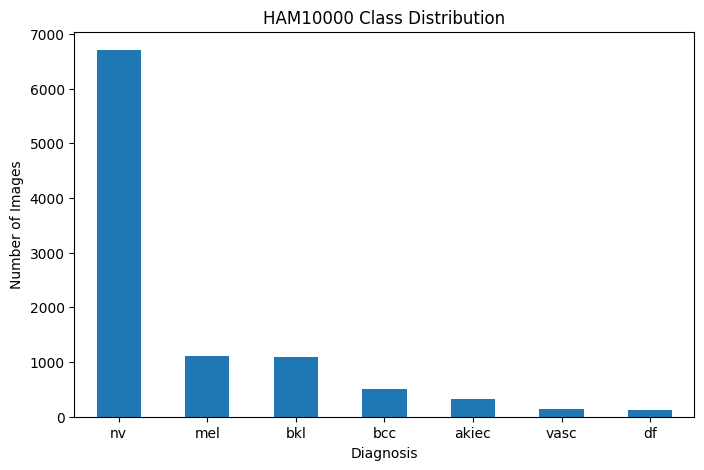

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
df["dx"].value_counts().plot(kind="bar")
plt.title("HAM10000 Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.show()

# 5. MEMORY-SAFE IMAGE PIPELINES

- Images are loaded lazily from disk.
- No full-dataset `.cache()` is used.
- `prefetch(1)` is used to keep RAM usage conservative.
- ResNet50 always uses the ImageNet preprocessing expected by the pretrained weights.

In [12]:
def preprocess_image_cnn(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize_with_pad(
        image,
        IMG_SIZE[0],
        IMG_SIZE[1],
    )
    image = tf.cast(image, tf.float32) / 255.0
    return image


def preprocess_image_resnet(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize_with_pad(
        image,
        IMG_SIZE[0],
        IMG_SIZE[1],
    )
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image


def make_dataset(split_df, preprocess_fn, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (split_df["image_path"].values, split_df["label"].values)
    )

    ds = ds.map(
        lambda path, label: (preprocess_fn(path), label),
        num_parallel_calls=1,
    )

    if shuffle:
        ds = ds.shuffle(
            buffer_size=min(len(split_df), 1000),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(1)
    return ds

In [13]:
# Standard datasets used by the non-balanced experiments
train_dataset_cnn = make_dataset(train_df, preprocess_image_cnn, shuffle=False)
val_dataset_cnn = make_dataset(val_df, preprocess_image_cnn, shuffle=False)

train_dataset_resnet = make_dataset(train_df, preprocess_image_resnet, shuffle=False)
val_dataset_resnet = make_dataset(val_df, preprocess_image_resnet, shuffle=False)

print("Standard datasets are ready.")

Standard datasets are ready.


In [14]:
def make_balanced_dataset():
    class_datasets = []

    for class_id in range(NUM_CLASSES):
        class_df = train_df[train_df["label"] == class_id]

        ds = tf.data.Dataset.from_tensor_slices(
            (class_df["image_path"].values, class_df["label"].values)
        )

        ds = ds.map(
            lambda path, label: (preprocess_image_resnet(path), label),
            num_parallel_calls=1,
        )

        ds = ds.shuffle(
            buffer_size=len(class_df),
            seed=SEED,
            reshuffle_each_iteration=True,
        )
        ds = ds.repeat()
        class_datasets.append(ds)

    ds = tf.data.Dataset.sample_from_datasets(
        class_datasets,
        weights=[1 / NUM_CLASSES] * NUM_CLASSES,
        seed=SEED,
    )

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(1)
    return ds

balanced_train_dataset = make_balanced_dataset()
steps_per_epoch = len(train_df) // BATCH_SIZE

print("Balanced dataset ready.")
print("Steps per epoch:", steps_per_epoch)

Balanced dataset ready.
Steps per epoch: 185


# 6. REUSABLE EVALUATION / SAVE TOOLS

These are the only helper functions used later. They keep the experiment sections short without hiding the experimental logic.

In [30]:
def load_saved_model(filename):
    # compile=False makes restoration work even for models with custom losses.
    # Evaluation only needs the trained weights and architecture.
    return tf.keras.models.load_model(
        os.path.join(PROJECT_DIR, filename),
        compile=False,
    )

# 6. MODEL DEVELOPMENT AND COMPARISON

The modeling stage compares a transparent CNN baseline with pretrained transfer-learning models. Class imbalance is handled in controlled experiments using training-set class weights and class-balanced sampling.

All new checkpoints use filenames beginning with `final_`, so the existing saved checkpoints in Google Drive are not overwritten.

In [23]:
# Existing saved checkpoints are available for restoration without retraining.
existing_checkpoints = [
    "resnet50_frozen_ce.keras",
    "resnet50_focal_loss.keras",
    "resnet50_finetuned.keras",
    "resnet50_balanced_sampling.keras",
    "resnet50_balanced_finetuned.keras",
    "resnet50_balanced_metadata_fusion.keras",
]

print("Saved checkpoints in the project folder:")
for filename in existing_checkpoints:
    path = os.path.join(PROJECT_DIR, filename)
    print(f"{filename}: {os.path.exists(path)}")

# Example restoration when a saved model is needed:
# saved_model = load_saved_model("resnet50_balanced_finetuned.keras")


Saved checkpoints in the project folder:
resnet50_frozen_ce.keras: True
resnet50_focal_loss.keras: True
resnet50_finetuned.keras: True
resnet50_balanced_sampling.keras: True
resnet50_balanced_finetuned.keras: True
resnet50_balanced_metadata_fusion.keras: True


In [22]:
# Raw images are loaded here; preprocessing and augmentation are handled inside each model.
def load_raw_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label


def make_raw_dataset(frame, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((
        frame["image_path"].values,
        frame["label"].values.astype(np.int32),
    ))
    ds = ds.map(load_raw_image, num_parallel_calls=1)
    if shuffle:
        ds = ds.shuffle(
            buffer_size=min(len(frame), 1000),
            seed=SEED,
            reshuffle_each_iteration=True,
        )
    return ds.batch(BATCH_SIZE).prefetch(1)

train_dataset = make_raw_dataset(train_df, shuffle=True)
val_dataset = make_raw_dataset(val_df, shuffle=False)
test_dataset = make_raw_dataset(test_df, shuffle=False)

print("Raw-image datasets are ready.")


Raw-image datasets are ready.


# 7. TRAINING AUGMENTATION AND CLASS WEIGHTS

Augmentation is applied only while training. Class weights are calculated from the training split only.

In [21]:
from sklearn.utils.class_weight import compute_class_weight

augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", seed=SEED),
    tf.keras.layers.RandomRotation(0.05, seed=SEED),
    tf.keras.layers.RandomZoom(0.10, seed=SEED),
], name="training_augmentation")

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_df["label"].values,
)
class_weights = {i: float(w) for i, w in enumerate(class_weights_array)}

print("Class weights:")
for name, weight in zip(class_names, class_weights_array):
    print(f"{name}: {weight:.4f}")


Class weights:
akiec: 4.7689
bcc: 2.7120
bkl: 1.3059
df: 12.8615
mel: 1.3181
nv: 0.2116
vasc: 10.6107


In [31]:
def make_balanced_raw_dataset():
    class_datasets = []

    for class_id in range(NUM_CLASSES):
        class_df = train_df[train_df["label"] == class_id]
        ds = tf.data.Dataset.from_tensor_slices((
            class_df["image_path"].values,
            class_df["label"].values.astype(np.int32),
        ))
        ds = ds.map(load_raw_image, num_parallel_calls=1)
        ds = ds.shuffle(
            buffer_size=len(class_df),
            seed=SEED,
            reshuffle_each_iteration=True,
        ).repeat()
        class_datasets.append(ds)

    ds = tf.data.Dataset.sample_from_datasets(
        class_datasets,
        weights=[1 / NUM_CLASSES] * NUM_CLASSES,
        seed=SEED,
    )
    return ds.batch(BATCH_SIZE).prefetch(1)

balanced_train_dataset = make_balanced_raw_dataset()
steps_per_epoch = len(train_df) // BATCH_SIZE
print("Balanced training dataset is ready.")
print("Steps per epoch:", steps_per_epoch)


Balanced training dataset is ready.
Steps per epoch: 185


In [24]:
def make_multimodal_dataset(frame, metadata_array, shuffle=False):
    """Return ((image, metadata), label) batches for the multimodal model."""
    ds = tf.data.Dataset.from_tensor_slices((
        frame["image_path"].values,
        metadata_array,
        frame["label"].values.astype(np.int32),
    ))

    def load_example(path, metadata, label):
        image, _ = load_raw_image(path, label)
        return (image, metadata), label

    ds = ds.map(load_example, num_parallel_calls=1)
    if shuffle:
        ds = ds.shuffle(
            buffer_size=min(len(frame), 1000),
            seed=SEED,
            reshuffle_each_iteration=True,
        )
    return ds.batch(BATCH_SIZE).prefetch(1)


def make_balanced_multimodal_dataset():
    class_datasets = []

    for class_id in range(NUM_CLASSES):
        class_mask = train_df["label"].values == class_id
        class_frame = train_df.loc[class_mask]
        class_metadata = train_metadata[class_mask]

        ds = tf.data.Dataset.from_tensor_slices((
            class_frame["image_path"].values,
            class_metadata,
            class_frame["label"].values.astype(np.int32),
        ))

        def load_example(path, metadata, label):
            image, _ = load_raw_image(path, label)
            return (image, metadata), label

        ds = ds.map(load_example, num_parallel_calls=1)
        ds = ds.shuffle(
            buffer_size=len(class_frame),
            seed=SEED,
            reshuffle_each_iteration=True,
        ).repeat()
        class_datasets.append(ds)

    ds = tf.data.Dataset.sample_from_datasets(
        class_datasets,
        weights=[1 / NUM_CLASSES] * NUM_CLASSES,
        seed=SEED,
    )
    return ds.batch(BATCH_SIZE).prefetch(1)


train_multimodal_dataset = make_balanced_multimodal_dataset()
val_multimodal_dataset = make_multimodal_dataset(val_df, val_metadata, shuffle=False)
test_multimodal_dataset = make_multimodal_dataset(test_df, test_metadata, shuffle=False)

print("Multimodal datasets are ready.")


Multimodal datasets are ready.


# 8. EVALUATION AND SAVE HELPERS


In [18]:
def evaluate_model(model, dataset, model_name):
    probabilities = model.predict(dataset, verbose=0)
    y_pred = np.argmax(probabilities, axis=1)
    y_true = np.concatenate([labels.numpy() for _, labels in dataset])

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    }

    print(f"\n{model_name}")
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Macro F1: {metrics['macro_f1']:.4f}")
    print(f"Balanced Accuracy: {metrics['balanced_accuracy']:.4f}")
    print("\nClassification report:")
    print(classification_report(
        y_true, y_pred, target_names=class_names, digits=4, zero_division=0
    ))
    return metrics, y_true, y_pred, probabilities


def clear_model(model):
    del model
    tf.keras.backend.clear_session()
    gc.collect()


def save_history(history, filename):
    with open(os.path.join(PROJECT_DIR, filename), "wb") as f:
        pickle.dump(history.history, f)


def load_history(filename):
    with open(os.path.join(PROJECT_DIR, filename), "rb") as f:
        return pickle.load(f)


# 9. MODEL BUILDER


In [17]:
def build_transfer_model(architecture):
    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = augmentation(inputs)

    if architecture == "ResNet50":
        x = tf.keras.applications.resnet50.preprocess_input(x)
        base = tf.keras.applications.ResNet50(
            include_top=False, weights="imagenet", input_shape=(224, 224, 3)
        )
    elif architecture == "EfficientNetB0":
        base = tf.keras.applications.EfficientNetB0(
            include_top=False, weights="imagenet", input_shape=(224, 224, 3)
        )
    elif architecture == "DenseNet121":
        x = tf.keras.applications.densenet.preprocess_input(x)
        base = tf.keras.applications.DenseNet121(
            include_top=False, weights="imagenet", input_shape=(224, 224, 3)
        )
    else:
        raise ValueError("Unknown architecture")

    base.trainable = False
    x = base(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs, name=architecture)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model, base


def compile_fine_tuning(model, base, unfreeze_last=30):
    base.trainable = True
    for layer in base.layers[:-unfreeze_last]:
        layer.trainable = False
    for layer in base.layers[-unfreeze_last:]:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5, clipnorm=1.0),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


# 10. CNN BASELINE


In [36]:
cnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),
    augmentation,
    tf.keras.layers.Rescaling(1.0 / 255.0),
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(NUM_CLASSES, activation="softmax"),
])
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

cnn_checkpoint = os.path.join(PROJECT_DIR, "final_cnn_baseline.keras")
cnn_history = cnn.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=8,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)],
    verbose=1,
)
cnn_metrics, _, _, _ = evaluate_model(cnn, val_dataset, "CNN Baseline")
save_history(cnn_history, "final_cnn_baseline_history.pkl")
cnn.save(cnn_checkpoint)
clear_model(cnn)


Epoch 1/8
186/186 ━━━━━━━━━━━━━━━━━━━━ 71s 321ms/step - accuracy: 0.7129 - loss: 0.9313 - val_accuracy: 0.6464 - val_loss: 1.9913
Epoch 2/8
186/186 ━━━━━━━━━━━━━━━━━━━━ 67s 260ms/step - accuracy: 0.6954 - loss: 0.9887 - val_accuracy: 0.6464 - val_loss: 1.4675
Epoch 3/8
186/186 ━━━━━━━━━━━━━━━━━━━━ 55s 259ms/step - accuracy: 0.6858 - loss: 1.0094 - val_accuracy: 0.6464 - val_loss: 1.3450
Epoch 4/8
186/186 ━━━━━━━━━━━━━━━━━━━━ 55s 258ms/step - accuracy: 0.6680 - loss: 0.9409 - val_accuracy: 0.6464 - val_loss: 2.1226
Epoch 5/8
186/186 ━━━━━━━━━━━━━━━━━━━━ 55s 263ms/step - accuracy: 0.6742 - loss: 1.0002 - val_accuracy: 0.6464 - val_loss: 1.5325
Epoch 6/8
186/186 ━━━━━━━━━━━━━━━━━━━━ 62s 302ms/step - accuracy: 0.6491 - loss: 0.9671 - val_accuracy: 0.6464 - val_loss: 2.3076

CNN Baseline
Accuracy: 0.6464
Macro F1: 0.1122
Balanced Accuracy: 0.1429

Classification report:
              precision    recall  f1-score   support

       akiec     0.0000    0.0000    0.0000        81
         bcc 

# 11. RESNET50 — FROZEN TRANSFER LEARNING


In [ ]:
resnet50, resnet50_base = build_transfer_model("ResNet50")
resnet50_checkpoint = os.path.join(PROJECT_DIR, "final_resnet50_transfer.keras")

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(resnet50_checkpoint, monitor="val_loss", save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-7),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
]

resnet50_history = resnet50.fit(
    train_dataset, validation_data=val_dataset, epochs=12, callbacks=callbacks, verbose=1
)
resnet50_metrics, _, _, _ = evaluate_model(resnet50, val_dataset, "ResNet50 Transfer Learning")
save_history(resnet50_history, "final_resnet50_transfer_history.pkl")
resnet50.save(resnet50_checkpoint)
clear_model(resnet50)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/12
186/186 ━━━━━━━━━━━━━━━━━━━━ 73s 321ms/step - accuracy: 0.6085 - loss: 1.4859 - val_accuracy: 0.6469 - val_loss: 1.8399 - learning_rate: 1.0000e-04
Epoch 2/12
186/186 ━━━━━━━━━━━━━━━━━━━━ 61s 293ms/step - accuracy: 0.6451 - loss: 1.2800 - val_accuracy: 0.6484 - val_loss: 1.6645 - learning_rate: 1.0000e-04
Epoch 3/12
186/186 ━━━━━━━━━━━━━━━━━━━━ 61s 297ms/step - accuracy: 0.6681 - loss: 1.1539 - val_accuracy: 0.6498 - val_loss: 1.5880 - learning_rate: 1.0000e-04
Epoch 4/12
186/186 ━━━━━━━━━━━━━━━━━━━━ 82s 297ms/step - accuracy: 0.6947 - loss: 1.0383 - val_accuracy: 0.6508 - val_loss: 1.5036 - learning_rate: 1.0000e-04
Epoch 5/12
186/186 ━━━━━━━━━━━━━━━━━━━━ 61s 301ms/step - accuracy: 0.6940 - loss: 1.0011 - val_accuracy: 0.6503 - val_loss: 1.4727 - learning_rate: 1.0000e-04
Epoch 6/12
186/186 ━━━━━━━━━━━━━━━━━━━━ 62s 295ms/step - accuracy: 0.7094 - loss: 0.9576 - val_accuracy: 0.6576 - val_loss: 1.3859 - learning_rate: 1.0000

# 12. RESNET50 — CLASS-WEIGHTED TRAINING


In [25]:
resnet50_w, _ = build_transfer_model("ResNet50")
weighted_checkpoint = os.path.join(PROJECT_DIR, "final_resnet50_class_weighted.keras")

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(weighted_checkpoint, monitor="val_loss", save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-7),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
]

weighted_history = resnet50_w.fit(
    train_dataset, validation_data=val_dataset, epochs=12,
    class_weight=class_weights, callbacks=callbacks, verbose=1
)
resnet50_w_metrics, _, _, _ = evaluate_model(
    resnet50_w, val_dataset, "ResNet50 + Class Weighting"
)
save_history(weighted_history, "final_resnet50_class_weighted_history.pkl")
resnet50_w.save(weighted_checkpoint)
clear_model(resnet50_w)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/12
186/186 ━━━━━━━━━━━━━━━━━━━━ 105s 417ms/step - accuracy: 0.3187 - loss: 2.6489 - val_accuracy: 0.4012 - val_loss: 1.7496 - learning_rate: 1.0000e-04
Epoch 2/12
186/186 ━━━━━━━━━━━━━━━━━━━━ 67s 314ms/step - accuracy: 0.3499 - loss: 2.2790 - val_accuracy: 0.6051 - val_loss: 1.2843 - learning_rate: 1.0000e-04
Epoch 3/12
186/186 ━━━━━━━━━━━━━━━━━━━━ 80s 317ms/step - accuracy: 0.3713 - loss: 2.0420 - val_accuracy: 0.6221 - val_loss: 1.1836 - learning_rate: 1.0000e-04
Epoch 4/12
186/186 ━━━━━━━━━━━━━━━━━━━━ 65s 313ms/step - accuracy: 0.3889 - loss: 1.8984 - val_accuracy: 0.6445 - val_loss: 1.0971 - learning_rate: 1.0000e-04
Epoch 5/12
186/186 ━━━━━━━━━━━━━━━━━━━━ 66s 322ms/step - accuracy: 0.4325 - loss: 1.7531 - val_accuracy: 0.6523 - val_loss: 1.0771 - learning_rate: 1.0000e-04
Epoch 6/12
186/186 ━━━━━━━━━━━━━━━━━━━━ 66s 315ms/step - accuracy: 0.4308 - loss: 1.6697 - val_accuracy: 0.6625 - val_loss: 1.0169 - learning_rate: 1.000

# 13. RESNET50 — BALANCED SAMPLING AND FINE-TUNING

This is the main imbalance-aware experiment. Training batches are sampled approximately equally across the seven lesion classes, followed by low-learning-rate fine-tuning of the final 30 backbone layers.

In [26]:
resnet50_bal, resnet50_bal_base = build_transfer_model("ResNet50")

# Stage 1: balanced sampling with a frozen ImageNet backbone.
balanced_head_history = resnet50_bal.fit(
    balanced_train_dataset,
    validation_data=val_dataset,
    steps_per_epoch=steps_per_epoch,
    epochs=6,
    verbose=1,
)

# Stage 2: fine-tune the last 30 layers at a lower learning rate.
resnet50_bal = compile_fine_tuning(resnet50_bal, resnet50_bal_base, unfreeze_last=30)
balanced_checkpoint = os.path.join(PROJECT_DIR, "final_resnet50_balanced_finetuned.keras")

balanced_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(balanced_checkpoint, monitor="val_loss", save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-7),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
]

balanced_ft_history = resnet50_bal.fit(
    balanced_train_dataset,
    validation_data=val_dataset,
    steps_per_epoch=steps_per_epoch,
    epochs=10,
    callbacks=balanced_callbacks,
    verbose=1,
)

resnet50_bal_metrics, _, _, _ = evaluate_model(
    resnet50_bal, val_dataset, "ResNet50 + Balanced Sampling + Fine-Tuning"
)
save_history(balanced_ft_history, "final_resnet50_balanced_finetuned_history.pkl")
resnet50_bal.save(balanced_checkpoint)
clear_model(resnet50_bal)


Epoch 1/6
185/185 ━━━━━━━━━━━━━━━━━━━━ 121s 339ms/step - accuracy: 0.1792 - loss: 2.5010 - val_accuracy: 0.1102 - val_loss: 2.4597
Epoch 2/6
185/185 ━━━━━━━━━━━━━━━━━━━━ 59s 320ms/step - accuracy: 0.2868 - loss: 1.9943 - val_accuracy: 0.0767 - val_loss: 2.7744
Epoch 3/6
185/185 ━━━━━━━━━━━━━━━━━━━━ 59s 320ms/step - accuracy: 0.3541 - loss: 1.7440 - val_accuracy: 0.0457 - val_loss: 3.3280
Epoch 4/6
185/185 ━━━━━━━━━━━━━━━━━━━━ 59s 318ms/step - accuracy: 0.4110 - loss: 1.5871 - val_accuracy: 0.0403 - val_loss: 3.4809
Epoch 5/6
185/185 ━━━━━━━━━━━━━━━━━━━━ 66s 358ms/step - accuracy: 0.4373 - loss: 1.4930 - val_accuracy: 0.0379 - val_loss: 3.8180
Epoch 6/6
185/185 ━━━━━━━━━━━━━━━━━━━━ 60s 328ms/step - accuracy: 0.4767 - loss: 1.3922 - val_accuracy: 0.0393 - val_loss: 3.9090
Epoch 1/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 146s 411ms/step - accuracy: 0.6142 - loss: 1.0429 - val_accuracy: 0.0384 - val_loss: 5.7139 - learning_rate: 1.0000e-05
Epoch 2/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 68s 366ms/step - ac

# 14. MULTIMODAL RESNET50 — IMAGE + CLINICAL METADATA

This is the metadata-fusion experiment. The image branch learns visual features with ResNet50, while a small metadata branch processes age, sex, and localization. The two feature vectors are concatenated before the final classifier.


In [27]:
def build_multimodal_resnet50():
    image_input = tf.keras.Input(shape=(224, 224, 3), name="image")
    metadata_input = tf.keras.Input(
        shape=(len(metadata_feature_names),), name="metadata"
    )

    # Image branch
    x = augmentation(image_input)
    x = tf.keras.applications.resnet50.preprocess_input(x)

    image_base = tf.keras.applications.ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=(224, 224, 3),
        name="resnet50_image_base",
    )
    image_base.trainable = False
    x = image_base(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D(name="image_gap")(x)
    x = tf.keras.layers.Dropout(0.4, name="image_dropout")(x)

    # Metadata branch
    m = tf.keras.layers.Dense(32, activation="relu", name="metadata_dense")(metadata_input)
    m = tf.keras.layers.Dropout(0.2, name="metadata_dropout")(m)

    # Fusion
    combined = tf.keras.layers.Concatenate(name="metadata_fusion")([x, m])
    combined = tf.keras.layers.Dense(64, activation="relu", name="fusion_dense")(combined)
    combined = tf.keras.layers.Dropout(0.3, name="fusion_dropout")(combined)
    output = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax", name="classifier")(combined)

    model = tf.keras.Model(
        inputs=[image_input, metadata_input],
        outputs=output,
        name="ResNet50_Multimodal",
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model, image_base


def compile_multimodal_fine_tuning(model, image_base, unfreeze_last=30):
    image_base.trainable = True
    for layer in image_base.layers[:-unfreeze_last]:
        layer.trainable = False
    for layer in image_base.layers[-unfreeze_last:]:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5, clipnorm=1.0),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


In [32]:
# Metadata fusion was already trained in the previous research workflow.
# Keep the completed experiment as an ablation; do not retrain it by default.
multimodal_checkpoint = os.path.join(
    PROJECT_DIR, "resnet50_balanced_metadata_fusion.keras"
)

if not os.path.exists(multimodal_checkpoint):
    raise FileNotFoundError(
        "The previously trained metadata-fusion checkpoint was not found. "
        "Restore it to HAM10000_Project before running this section."
    )

multimodal_model = load_saved_model("resnet50_balanced_metadata_fusion.keras")

multimodal_metrics, _, _, _ = evaluate_model(
    multimodal_model,
    val_multimodal_dataset,
    "ResNet50 + Balanced Sampling + Metadata Fusion (previously trained)",
)

clear_model(multimodal_model)

print("Metadata-fusion ablation restored from the existing checkpoint; no retraining performed.")


/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'image': 'image', 'metadata': 'metadata'}
Received: inputs=('Tensor(shape=(32, 224, 224, 3))', 'Tensor(shape=(32, 19))')
  warnings.warn(msg)
/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'image': 'image', 'metadata': 'metadata'}
Received: inputs=('Tensor(shape=(None, 224, 224, 3))', 'Tensor(shape=(None, 19))')
  warnings.warn(msg)



ResNet50 + Balanced Sampling + Metadata Fusion (previously trained)
Accuracy: 0.2341
Macro F1: 0.1894
Balanced Accuracy: 0.3806

Classification report:
              precision    recall  f1-score   support

       akiec     0.1622    0.2963    0.2096        81
         bcc     0.1975    0.1584    0.1758       101
         bkl     0.3587    0.2705    0.3084       244
          df     0.0465    0.8519    0.0881        27
         mel     0.4706    0.0648    0.1139       247
          nv     0.8974    0.2367    0.3746      1331
        vasc     0.0287    0.7857    0.0554        28

    accuracy                         0.2341      2059
   macro avg     0.3088    0.3806    0.1894      2059
weighted avg     0.6962    0.2341    0.3111      2059

Metadata-fusion ablation restored from the existing checkpoint; no retraining performed.


# 14. EFFICIENTNETB0 — BALANCED FINE-TUNING


In [33]:
efficientnet, efficientnet_base = build_transfer_model("EfficientNetB0")
efficientnet_checkpoint = os.path.join(PROJECT_DIR, "final_efficientnetb0_balanced_finetuned.keras")

efficientnet_head = efficientnet.fit(
    balanced_train_dataset, validation_data=val_dataset,
    steps_per_epoch=steps_per_epoch, epochs=6, verbose=1
)

efficientnet = compile_fine_tuning(efficientnet, efficientnet_base, unfreeze_last=30)
efficientnet_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(efficientnet_checkpoint, monitor="val_loss", save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-7),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
]

efficientnet_history = efficientnet.fit(
    balanced_train_dataset, validation_data=val_dataset,
    steps_per_epoch=steps_per_epoch, epochs=10,
    callbacks=efficientnet_callbacks, verbose=1
)
efficientnet_metrics, _, _, _ = evaluate_model(
    efficientnet, val_dataset, "EfficientNetB0 + Balanced Sampling + Fine-Tuning"
)
save_history(efficientnet_history, "final_efficientnetb0_balanced_finetuned_history.pkl")
efficientnet.save(efficientnet_checkpoint)
clear_model(efficientnet)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/6
185/185 ━━━━━━━━━━━━━━━━━━━━ 120s 321ms/step - accuracy: 0.2150 - loss: 1.9212 - val_accuracy: 0.5007 - val_loss: 1.6162
Epoch 2/6
185/185 ━━━━━━━━━━━━━━━━━━━━ 48s 263ms/step - accuracy: 0.3333 - loss: 1.7255 - val_accuracy: 0.5381 - val_loss: 1.5194
Epoch 3/6
185/185 ━━━━━━━━━━━━━━━━━━━━ 53s 290ms/step - accuracy: 0.4079 - loss: 1.5924 - val_accuracy: 0.5556 - val_loss: 1.4338
Epoch 4/6
185/185 ━━━━━━━━━━━━━━━━━━━━ 51s 276ms/step - accuracy: 0.4390 - loss: 1.5067 - val_accuracy: 0.5663 - val_loss: 1.3546
Epoch 5/6
185/185 ━━━━━━━━━━━━━━━━━━━━ 49s 265ms/step - accuracy: 0.4779 - loss: 1.4447 - val_accuracy: 0.5697 - val_loss: 1.3135
Epoch 6/6
185/185 ━━━━━━━━━━━━━━━━━━━━ 51s 276ms/step - accuracy: 0.4968 - loss: 1.3882 - val_accuracy: 0.5886 - val_loss: 1.2483
Epoch 1/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 118s 313ms/step - accuracy: 0.5301 - loss: 1.2861 - val_accuracy: 0.6003 - val_loss: 1.1092 - learning_rate: 1.0000e-05
Epoch 2/

# 15. DENSENET121 — BALANCED FINE-TUNING


In [34]:
densenet, densenet_base = build_transfer_model("DenseNet121")
densenet_checkpoint = os.path.join(PROJECT_DIR, "final_densenet121_balanced_finetuned.keras")

densenet.fit(
    balanced_train_dataset, validation_data=val_dataset,
    steps_per_epoch=steps_per_epoch, epochs=6, verbose=1
)

densenet = compile_fine_tuning(densenet, densenet_base, unfreeze_last=30)
densenet_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(densenet_checkpoint, monitor="val_loss", save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-7),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
]

densenet_history = densenet.fit(
    balanced_train_dataset, validation_data=val_dataset,
    steps_per_epoch=steps_per_epoch, epochs=10,
    callbacks=densenet_callbacks, verbose=1
)
densenet_metrics, _, _, _ = evaluate_model(
    densenet, val_dataset, "DenseNet121 + Balanced Sampling + Fine-Tuning"
)
save_history(densenet_history, "final_densenet121_balanced_finetuned_history.pkl")
densenet.save(densenet_checkpoint)
clear_model(densenet)


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/6
185/185 ━━━━━━━━━━━━━━━━━━━━ 127s 341ms/step - accuracy: 0.1811 - loss: 2.2794 - val_accuracy: 0.2788 - val_loss: 1.8012
Epoch 2/6
185/185 ━━━━━━━━━━━━━━━━━━━━ 52s 279ms/step - accuracy: 0.2431 - loss: 2.0035 - val_accuracy: 0.3667 - val_loss: 1.6528
Epoch 3/6
185/185 ━━━━━━━━━━━━━━━━━━━━ 56s 306ms/step - accuracy: 0.3000 - loss: 1.8406 - val_accuracy: 0.4424 - val_loss: 1.5624
Epoch 4/6
185/185 ━━━━━━━━━━━━━━━━━━━━ 53s 289ms/step - accuracy: 0.3507 - loss: 1.7201 - val_accuracy: 0.4978 - val_loss: 1.4737
Epoch 5/6
185/185 ━━━━━━━━━━━━━━━━━━━━ 54s 292ms/step - accuracy: 0.3861 - loss: 1.6201 - val_accuracy: 0.5250 - val_loss: 1.4126
Epoch 6/6
185/185 ━━━━━━━━━━━━━━━━━━━━ 54s 295ms/step - accuracy: 0.4084 - loss: 1.5554 - val_accuracy: 0.5410 - val_loss: 1.3595
Epoch 1/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 133s 396ms/step - accuracy: 0.4341 - loss: 1.4974 - val_accuracy: 0.5556 - val_loss: 1.3047 - learning_rate: 1.0000e-05
Epoch 2/

# 16. VALIDATION RESULTS

The test set is not used here. Model selection is based on validation performance, with Macro F1 and Balanced Accuracy emphasized because the dataset is highly imbalanced.

In [35]:
results = pd.DataFrame([
    {"Model": "CNN Baseline", **cnn_metrics},
    {"Model": "ResNet50 Transfer Learning", **resnet50_metrics},
    {"Model": "ResNet50 + Class Weighting", **resnet50_w_metrics},
    {"Model": "ResNet50 + Balanced Sampling + Fine-Tuning", **resnet50_bal_metrics},
    {"Model": "ResNet50 + Balanced Sampling + Metadata Fusion", **multimodal_metrics},
    {"Model": "EfficientNetB0 + Balanced Sampling + Fine-Tuning", **efficientnet_metrics},
    {"Model": "DenseNet121 + Balanced Sampling + Fine-Tuning", **densenet_metrics},
])

results = results.sort_values(
    ["macro_f1", "balanced_accuracy", "accuracy"], ascending=False
).reset_index(drop=True)

results


NameError: name 'cnn_metrics' is not defined

# 17. CONFUSION MATRIX AND PER-CLASS PERFORMANCE


Selected model from validation results: ResNet50 + Balanced Sampling + Fine-Tuning
Checkpoint: resnet50_balanced_finetuned.keras

Selected Model — Validation
Accuracy: 0.6105
Macro F1: 0.2814
Balanced Accuracy: 0.3078

Classification report:
              precision    recall  f1-score   support

       akiec     0.1387    0.2346    0.1743        81
         bcc     0.2917    0.0693    0.1120       101
         bkl     0.3083    0.4549    0.3675       244
          df     0.1111    0.1852    0.1389        27
         mel     0.8750    0.0283    0.0549       247
          nv     0.7557    0.8249    0.7888      1331
        vasc     0.3125    0.3571    0.3333        28

    accuracy                         0.6105      2059
   macro avg     0.3990    0.3078    0.2814      2059
weighted avg     0.6555    0.6105    0.5787      2059



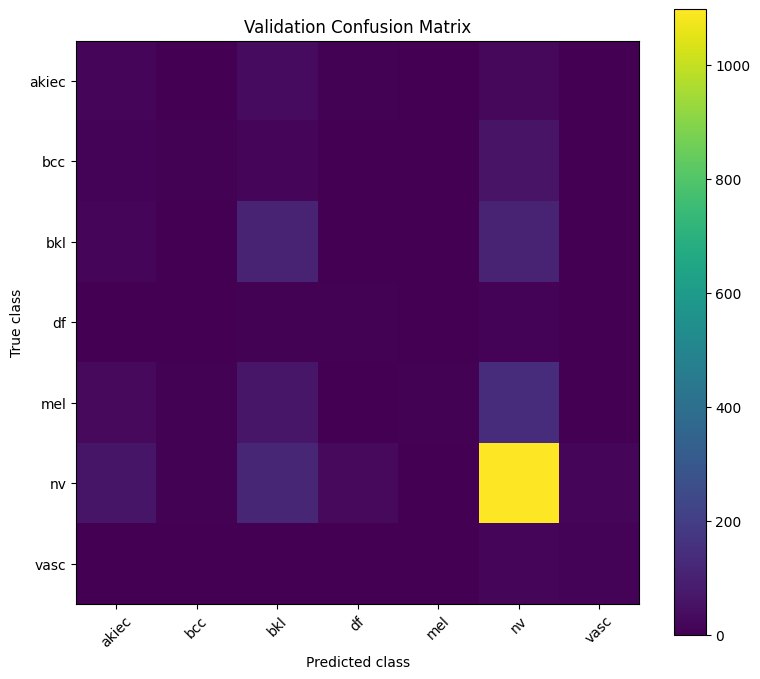

In [ ]:
# Select the final model using validation performance only.
# Primary criterion: Macro F1. Ties are resolved by Balanced Accuracy, then Accuracy.
MODEL_FILES = {
    "CNN Baseline": None,
    "ResNet50 Transfer Learning": "final_resnet50_transfer.keras",
    "ResNet50 + Class Weighting": "final_resnet50_class_weighted.keras",
    "ResNet50 + Balanced Sampling + Fine-Tuning": "resnet50_balanced_finetuned.keras",
    "ResNet50 + Balanced Sampling + Metadata Fusion": "resnet50_balanced_metadata_fusion.keras",
    "EfficientNetB0 + Balanced Sampling + Fine-Tuning": "final_efficientnetb0_balanced_finetuned.keras",
    "DenseNet121 + Balanced Sampling + Fine-Tuning": "final_densenet121_balanced_finetuned.keras",
}

results = results.copy()
results = results[results["Model"].isin(MODEL_FILES)].reset_index(drop=True)

if results.empty:
    raise ValueError("No validation results are available for final model selection.")

best_row = results.iloc[0]
BEST_MODEL_NAME = best_row["Model"]
BEST_MODEL_FILE = MODEL_FILES[BEST_MODEL_NAME]

if BEST_MODEL_FILE is None:
    raise ValueError(
        "The CNN baseline is not a saved transfer-learning checkpoint. "
        "Select a saved transfer-learning model for the locked final test evaluation."
    )

print(f"Selected model from validation results: {BEST_MODEL_NAME}")
print(f"Checkpoint: {BEST_MODEL_FILE}")

best_model = tf.keras.models.load_model(
    os.path.join(PROJECT_DIR, BEST_MODEL_FILE),
    compile=False,
)

best_metrics, y_val, y_val_pred, y_val_prob = evaluate_model(
    best_model, val_dataset, "Selected Model — Validation"
)

cm = confusion_matrix(y_val, y_val_pred, labels=np.arange(NUM_CLASSES))
plt.figure(figsize=(8, 7))
plt.imshow(cm)
plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.xticks(range(NUM_CLASSES), class_names, rotation=45)
plt.yticks(range(NUM_CLASSES), class_names)
plt.colorbar()
plt.tight_layout()
plt.show()


# 18. FINAL TEST EVALUATION — DO THIS ONCE

Run this section only after the final model has been selected from the validation results. The test set remains locked until this point.

In [ ]:
FINAL_MODEL_FILE = BEST_MODEL_FILE
final_model = tf.keras.models.load_model(
    os.path.join(PROJECT_DIR, FINAL_MODEL_FILE),
    compile=False,
)

final_test_dataset = (
    test_multimodal_dataset
    if BEST_MODEL_NAME == "ResNet50 + Balanced Sampling + Metadata Fusion"
    else test_dataset
)

final_metrics, y_test, y_test_pred, y_test_prob = evaluate_model(
    final_model, final_test_dataset, "FINAL TEST — LOCKED EVALUATION"
)

with open(os.path.join(PROJECT_DIR, "final_test_metrics.pkl"), "wb") as f:
    pickle.dump(
        {
            "model_name": BEST_MODEL_NAME,
            "checkpoint": FINAL_MODEL_FILE,
            "metrics": final_metrics,
        },
        f,
    )

print("Final test evaluation saved to Drive.")



FINAL TEST — LOCKED EVALUATION
Accuracy: 0.6316
Macro F1: 0.2601
Balanced Accuracy: 0.2913

Classification report:
              precision    recall  f1-score   support

       akiec     0.1628    0.3088    0.2132        68
         bcc     0.1176    0.0200    0.0342       100
         bkl     0.2796    0.4488    0.3446       205
          df     0.0426    0.0909    0.0580        22
         mel     1.0000    0.0090    0.0179       222
          nv     0.7822    0.8379    0.8091      1363
        vasc     0.3667    0.3235    0.3438        34

    accuracy                         0.6316      2014
   macro avg     0.3931    0.2913    0.2601      2014
weighted avg     0.6860    0.6316    0.5999      2014

Final test evaluation saved to Drive.


# 18.1 ADVANCED TEST METRICS

These metrics complement accuracy because HAM10000 is highly imbalanced. Sensitivity and specificity are reported for each class, and AUPRC is calculated for all seven classes.


In [ ]:
def advanced_class_metrics(y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(NUM_CLASSES))
    rows = []

    for i, class_name in enumerate(class_names):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - tp - fn - fp

        sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
        specificity = tn / (tn + fp) if (tn + fp) else 0.0

        rows.append({
            "Class": class_name,
            "Sensitivity": sensitivity,
            "Specificity": specificity,
        })

    class_table = pd.DataFrame(rows)
    y_true_bin = label_binarize(y_true, classes=np.arange(NUM_CLASSES))
    auprc_rows = []

    for i, class_name in enumerate(class_names):
        auprc = average_precision_score(y_true_bin[:, i], y_prob[:, i])
        auprc_rows.append({"Class": class_name, "AUPRC": auprc})

    auprc_table = pd.DataFrame(auprc_rows)

    print("Weighted F1:", f1_score(y_true, y_pred, average="weighted", zero_division=0))
    print("\nPer-class sensitivity and specificity:")
    print(class_table.to_string(index=False))
    print("\nPer-class AUPRC:")
    print(auprc_table.to_string(index=False))

    return class_table, auprc_table


class_metrics_table, auprc_table = advanced_class_metrics(
    y_test, y_test_pred, y_test_prob
)


Weighted F1: 0.599920705909592

Per-class sensitivity and specificity:
Class  Sensitivity  Specificity
akiec     0.308824     0.944502
  bcc     0.020000     0.992163
  bkl     0.448780     0.868988
   df     0.090909     0.977410
  mel     0.009009     1.000000
   nv     0.837858     0.511521
 vasc     0.323529     0.990404

Per-class AUPRC:
Class    AUPRC
akiec 0.160617
  bcc 0.148170
  bkl 0.304419
   df 0.025142
  mel 0.149007
   nv 0.835897
 vasc 0.246250


# 18.2 UNCERTAINTY — MONTE CARLO DROPOUT

MC Dropout runs the model several times with dropout active. Stable predictions have low variation; uncertain predictions have higher variation.


In [ ]:
def mc_dropout_predict(model, dataset, passes=20):
    # Run the deterministic feature graph with training=False, then activate
    # only the model's Dropout layers stochastically. This avoids stochastic
    # augmentation and BatchNorm updates during uncertainty estimation.
    is_multimodal = (
        len(model.inputs) == 2
        and "image_dropout" in [layer.name for layer in model.layers]
    )

    if is_multimodal:
        image_dropout = model.get_layer("image_dropout")
        metadata_dropout = model.get_layer("metadata_dropout")
        fusion_dense = model.get_layer("fusion_dense")
        fusion_dropout = model.get_layer("fusion_dropout")
        classifier = model.get_layer("classifier")

        feature_model = tf.keras.Model(
            model.inputs,
            [image_dropout.input, metadata_dropout.input],
        )

        def predict_batch(inputs):
            image_features, metadata_features = feature_model(inputs, training=False)
            image_features = image_dropout(image_features, training=True)
            metadata_features = metadata_dropout(metadata_features, training=True)
            fused = tf.concat([image_features, metadata_features], axis=-1)
            fused = fusion_dense(fused, training=False)
            fused = fusion_dropout(fused, training=True)
            return classifier(fused, training=False)

    else:
        dropout = next(
            (layer for layer in model.layers if isinstance(layer, tf.keras.layers.Dropout)),
            None,
        )
        if dropout is None:
            raise ValueError("The selected model has no Dropout layer for MC Dropout.")

        classifier = model.layers[-1]
        feature_model = tf.keras.Model(model.inputs, dropout.input)

        def predict_batch(inputs):
            features = feature_model(inputs, training=False)
            features = dropout(features, training=True)
            return classifier(features, training=False)

    all_passes = []
    y_true = None

    for _ in range(passes):
        probabilities = []
        labels = []

        for inputs, batch_labels in dataset:
            batch_prob = predict_batch(inputs).numpy()
            probabilities.append(batch_prob)
            labels.append(batch_labels.numpy())

        all_passes.append(np.concatenate(probabilities, axis=0))
        if y_true is None:
            y_true = np.concatenate(labels, axis=0)

    all_passes = np.stack(all_passes, axis=0)
    mean_prob = all_passes.mean(axis=0)
    std_prob = all_passes.std(axis=0)
    predictions = np.argmax(mean_prob, axis=1)
    confidence = np.max(mean_prob, axis=1)

    entropy = -np.sum(
        mean_prob * np.log(np.clip(mean_prob, 1e-8, 1.0)), axis=1
    )
    uncertainty = std_prob.mean(axis=1)

    return y_true, mean_prob, predictions, confidence, uncertainty, entropy


final_test_dataset_for_uncertainty = (
    test_multimodal_dataset
    if BEST_MODEL_NAME == "ResNet50 + Balanced Sampling + Metadata Fusion"
    else test_dataset
)

(
    y_test_mc,
    y_test_mc_prob,
    y_test_mc_pred,
    test_confidence,
    test_uncertainty,
    test_entropy,
) = mc_dropout_predict(
    final_model, final_test_dataset_for_uncertainty, passes=20
)

print("MC Dropout passes: 20")
print("Mean confidence:", float(test_confidence.mean()))
print("Mean uncertainty:", float(test_uncertainty.mean()))
print("Mean predictive entropy:", float(test_entropy.mean()))


MC Dropout passes: 20
Mean confidence: 0.5924033522605896
Mean uncertainty: 0.09743914008140564
Mean predictive entropy: 1.1257295608520508


# 18.3 CALIBRATION — RELIABILITY DIAGRAM AND ECE


Expected Calibration Error (ECE): 0.0744


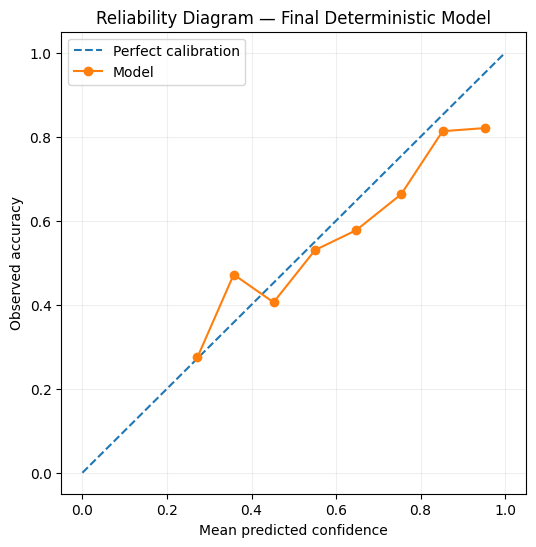

In [ ]:
def expected_calibration_error(y_true, probabilities, n_bins=10):
    confidence = np.max(probabilities, axis=1)
    predictions = np.argmax(probabilities, axis=1)
    correct = (predictions == y_true).astype(np.float32)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        if i == n_bins - 1:
            mask = (confidence >= bin_edges[i]) & (confidence <= bin_edges[i + 1])
        else:
            mask = (confidence >= bin_edges[i]) & (confidence < bin_edges[i + 1])

        if np.any(mask):
            bin_accuracy = correct[mask].mean()
            bin_confidence = confidence[mask].mean()
            ece += mask.mean() * abs(bin_accuracy - bin_confidence)

    return float(ece)


def plot_reliability_diagram(y_true, probabilities, n_bins=10):
    confidence = np.max(probabilities, axis=1)
    predictions = np.argmax(probabilities, axis=1)
    correct = (predictions == y_true).astype(np.float32)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_confidence = []
    bin_accuracy = []

    for i in range(n_bins):
        if i == n_bins - 1:
            mask = (confidence >= bin_edges[i]) & (confidence <= bin_edges[i + 1])
        else:
            mask = (confidence >= bin_edges[i]) & (confidence < bin_edges[i + 1])

        if np.any(mask):
            bin_confidence.append(confidence[mask].mean())
            bin_accuracy.append(correct[mask].mean())

    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.plot(bin_confidence, bin_accuracy, marker="o", label="Model")
    plt.xlabel("Mean predicted confidence")
    plt.ylabel("Observed accuracy")
    plt.title("Reliability Diagram — Final Deterministic Model")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


# Calibration is reported on the locked test predictions from the selected
# deterministic model. MC Dropout uncertainty is reported separately above.
ece = expected_calibration_error(y_test, y_test_prob)
print(f"Expected Calibration Error (ECE): {ece:.4f}")
plot_reliability_diagram(y_test, y_test_prob)


# 18.4 EXPLAINABILITY — GRAD-CAM

Grad-CAM is used on representative correct and incorrect predictions to inspect whether the model focuses on the lesion region rather than obvious background artifacts.


In [ ]:
def find_last_conv_layer(model):
    # ResNet50's final convolutional feature map.
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.Model):
            for sublayer in reversed(layer.layers):
                if isinstance(sublayer, tf.keras.layers.Conv2D):
                    return layer.name, sublayer.name
        if isinstance(layer, tf.keras.layers.Conv2D):
            return None, layer.name
    raise ValueError("No convolutional layer was found.")


def make_gradcam_heatmap(model, image, metadata=None, class_index=None):
    # Works with both the image-only ResNet50 model and the multimodal model.
    nested_name, conv_name = find_last_conv_layer(model)

    if nested_name is not None:
        base = model.get_layer(nested_name)
        last_conv = base.get_layer(conv_name)
        grad_model = tf.keras.Model(
            inputs=model.inputs,
            outputs=[last_conv.output, model.output],
        )
        inputs = [image, metadata] if metadata is not None else [image]
    else:
        last_conv = model.get_layer(conv_name)
        grad_model = tf.keras.Model(
            inputs=model.inputs,
            outputs=[last_conv.output, model.output],
        )
        inputs = image

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(inputs, training=False)
        if class_index is None:
            class_index = tf.argmax(predictions[0])
        class_score = predictions[:, class_index]

    gradients = tape.gradient(class_score, conv_outputs)
    weights = tf.reduce_mean(gradients, axis=(1, 2))
    heatmap = tf.reduce_sum(conv_outputs * weights[:, None, None, :], axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap[0]
    heatmap /= tf.maximum(tf.reduce_max(heatmap), 1e-8)

    return heatmap.numpy(), int(class_index), predictions.numpy()[0]


def show_gradcam(image, heatmap, title):
    heatmap = tf.image.resize(heatmap[..., None], IMG_SIZE).numpy().squeeze()
    heatmap = np.uint8(255 * heatmap)

    plt.figure(figsize=(5, 5))
    plt.imshow(image.astype(np.uint8))
    plt.imshow(heatmap, cmap="jet", alpha=0.4)
    plt.title(title)
    plt.axis("off")
    plt.show()


print("Grad-CAM helpers are ready. Select representative correct/incorrect samples from the final test set for visual inspection.")


Grad-CAM helpers are ready. Select representative correct/incorrect samples from the final test set for visual inspection.


# 19. RESEARCH INTERPRETATION

Report the selected model and explain why it was selected using validation Macro F1,
Balanced Accuracy, and Accuracy. Summarize the effect of class imbalance handling,
fine-tuning, and the metadata-fusion ablation. Report final locked-test performance
with Macro F1, Weighted F1, per-class sensitivity/specificity, and AUPRC. Interpret
MC Dropout uncertainty and calibration separately from discrimination metrics.
Use Grad-CAM as an interpretability aid to inspect representative validation examples
and possible attention to lesion versus background artifacts. Do not describe the
model as a clinical diagnostic tool.


In [ ]:
# Grad-CAM is inspected on validation examples after model selection.
# The test set remains reserved for the locked quantitative evaluation.
def prepare_display_image(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    return image.numpy().astype(np.uint8)


selected_indices = []
for class_id, class_name in enumerate(class_names):
    class_indices = np.where(y_val == class_id)[0]
    correct = [i for i in class_indices if y_val_pred[i] == class_id]
    incorrect = [i for i in class_indices if y_val_pred[i] != class_id]

    if correct:
        selected_indices.append((correct[0], f"{class_name} — Correct"))
    if incorrect:
        selected_indices.append((incorrect[0], f"{class_name} — Misclassified"))

# Keep the visualization manageable while covering all classes where examples exist.
for sample_index, case_type in selected_indices:
    image = prepare_display_image(val_df.iloc[sample_index]["image_path"])
    image_tensor = tf.expand_dims(tf.cast(image, tf.float32), axis=0)

    if BEST_MODEL_NAME == "ResNet50 + Balanced Sampling + Metadata Fusion":
        metadata_tensor = tf.convert_to_tensor(
            val_metadata[sample_index:sample_index + 1], dtype=tf.float32
        )
    else:
        metadata_tensor = None

    heatmap, predicted_class, probabilities = make_gradcam_heatmap(
        final_model, image_tensor, metadata_tensor
    )

    true_name = class_names[int(y_val[sample_index])]
    predicted_name = class_names[predicted_class]
    show_gradcam(
        image,
        heatmap,
        f"{case_type} | True: {true_name} | Predicted: {predicted_name}",
    )


AttributeError: The layer sequential_6 has never been called and thus has no defined output.

# 20. REPRODUCIBILITY CHECKLIST

- Fixed random seed: 42
- Lesion-level split using `lesion_id`
- Existing split CSVs reused after restart
- Training augmentation only
- Class weights computed from training data only
- Balanced sampling uses the training split only
- Metadata fusion is retained as a previously completed ablation and is not retrained by default
- Validation used for model selection
- Test set remains locked until the final model is selected
- Final quantitative evaluation includes Accuracy, Macro F1, Weighted F1, Balanced Accuracy
- Per-class Sensitivity and Specificity are reported
- Per-class AUPRC is reported for all classes, including rare classes
- MC Dropout uses 20 stochastic passes with Dropout activated while augmentation and BatchNorm remain in inference mode
- Calibration is assessed with ECE and a reliability diagram on the locked final predictions
- Grad-CAM is inspected on representative validation examples across classes
- Images are loaded lazily with conservative `prefetch(1)` to reduce RAM use


# 21. CRASH-SAFE WORKFLOW

### New Colab session
1. Run Sections **0–5**.
2. Confirm the split is **5942 / 2059 / 2014** with zero lesion overlap.
3. Restore a saved checkpoint or run the next training experiment.

### After a completed experiment
Confirm the `.keras` checkpoint and history file are in `HAM10000_Project` before moving on.

### If Colab crashes during training
Load the latest saved `final_*.keras` checkpoint or an existing saved checkpoint. Do not recreate the split.

### RAM rule
Never load all images into NumPy and never add `.cache()` to the full image dataset.